# Master Large-Model Visualization, Results, Targets, and PRT Workflow

This is the canonical integration notebook for the new `myflopy` result-review stack. By default it builds and runs a **10,000-cell, four-layer, six-period DISV/Voronoi model** with CHD, GHB, DRN, UZF, SFR, two lakes, MVR routing, canonical observations, standalone Matplotlib sliders, Plotly animations, and MF6 PRT.

The default `full` profile is intentionally substantial. Automated tests set `SIMPLE_MODFLOW_MASTER_PROFILE=validation`, which preserves the same package topology on a smaller grid.

In [1]:
from __future__ import annotations

import os
from datetime import datetime
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import LineString

import myflopy as mf
from myflopy.modflow.mf6 import plot_model_cross_section

sys.path.append(str(Path(r'C:\Users\lukem\Python\Projects\myflopy\examples\mf6')))


from visualization_prt_master_support import (
    MasterExampleConfig,
    build_transient_model,
    representative_cells,
)

PROFILE = os.environ.get("SIMPLE_MODFLOW_MASTER_PROFILE", "full").lower()
RUN_PRT = os.environ.get("SIMPLE_MODFLOW_MASTER_RUN_PRT", "1") == "1"
EXPORT_3D = os.environ.get("SIMPLE_MODFLOW_MASTER_EXPORT_3D", "1") == "1"
EXPORT_ALL_SLIDERS = os.environ.get("SIMPLE_MODFLOW_MASTER_EXPORT_ALL_SLIDERS", "1") == "1"
EXPORT_PLOTLY_SECTION = os.environ.get("SIMPLE_MODFLOW_MASTER_EXPORT_PLOTLY_SECTION", "1") == "1"
FRAME_STRIDE = int(os.environ.get("SIMPLE_MODFLOW_MASTER_FRAME_STRIDE", "1"))
MAX_FRAMES = os.environ.get("SIMPLE_MODFLOW_MASTER_MAX_FRAMES")
MAX_FRAMES = None if MAX_FRAMES is None else int(MAX_FRAMES)
RESUME_EXPORTS = os.environ.get("SIMPLE_MODFLOW_MASTER_RESUME_EXPORTS", "1") == "1"
config = MasterExampleConfig.validation() if PROFILE == "validation" else MasterExampleConfig()

repo_root = Path(mf.__file__).resolve().parents[2]
run_id = os.environ.get("SIMPLE_MODFLOW_MASTER_RUN_ID", datetime.now().strftime("%Y%m%d_%H%M%S"))
artifact_root = repo_root / "examples" / "mf6" / "artifacts" / f"master_visualization_prt_{PROFILE}_{run_id}"
artifact_root.mkdir(parents=True, exist_ok=True)
html_dir = artifact_root / "html"
html_dir.mkdir(exist_ok=True)

print(f"Profile: {PROFILE}")
print(f"Plan-view cells: {config.ncpl:,}")
print(f"Layers: {config.nlay}; total GWF cells: {config.ncpl * config.nlay:,}")
print(f"Stress periods: {config.nper}")

Profile: full
Plan-view cells: 10,000
Layers: 4; total GWF cells: 40,000
Stress periods: 6


## 1. Build the package-rich model

The support builder creates all geometry in code, writes temporary GeoPackages for the surface-water intersections, and attaches canonical targets before the run. The resulting object is a normal `SimulationBase` model.

In [2]:
model = build_transient_model(artifact_root / "gwf", config=config, name="master_complex")
cells = representative_cells(config)

assert model.gwf.modelgrid.grid_type == "vertex"
assert model.gwf.modelgrid.ncpl == config.ncpl
assert model.gwf.modelgrid.nlay == config.nlay
if PROFILE == "full":
    assert model.gwf.modelgrid.ncpl >= 10_000

pd.DataFrame(
    {
        "metric": ["ncpl", "nlay", "total cells", "nper", "package count"],
        "value": [config.ncpl, config.nlay, config.ncpl * config.nlay, config.nper, len(model.gwf.package_names)],
    }
)

VoronoiGrid initializing.
Voronoi grid initialized.
Imported 1 features from C:\Users\lukem\Python\Projects\myflopy\examples\mf6\artifacts\master_visualization_prt_full_20260606_174842\gwf\inputs\north_lake.gpkg
Imported 1 features from C:\Users\lukem\Python\Projects\myflopy\examples\mf6\artifacts\master_visualization_prt_full_20260606_174842\gwf\inputs\south_lake.gpkg
Generating connections (rectangular mode) for lake 0
getting connectivity properties (iac, ja, cl12, hwva, nja)
Generating connections (rectangular mode) for lake 1


C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:302: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(
C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


,metric,value
0,ncpl,10000
1,nlay,4
2,total cells,40000
3,nper,6
4,package count,16


In [3]:
required_packages = {"disv", "npf", "sto", "chd", "ghb", "drn", "lak", "sfr", "mvr", "uzf", "oc"}
actual_packages = set(model.gwf.package_names)
assert required_packages <= actual_packages
sorted(actual_packages)

C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\flopy\mf6\mfmodel.py:278: DeprecationWarning: This method is for internal use only and will be deprecated.
  warnings.warn(


['chd',
 'disv',
 'drn',
 'drn_flow_obs',
 'ghb',
 'gwf_obs',
 'ic',
 'lak',
 'lak_obs',
 'mvr',
 'npf',
 'oc',
 'sfr',
 'sfr_obs',
 'sto',
 'uzf']

## 2. Inspect canonical groups, targets, and MF6 observations

The same target objects define observation locations, attach valid MF6 observation records, and later compare simulated results. SFR stage and flow definitions are combined into one SFR `OBS6` child because MF6 permits only one `OBS6` reference per package.

In [4]:
target_summary = pd.DataFrame(
    {
        "target": ["heads", "lake_stage", "sfr_stage", "sfr_flow", "drn_flow"],
        "type": [
            type(model.targets.heads.targets).__name__,
            type(model.targets.lake_stage.targets).__name__,
            type(model.targets.sfr_stage.targets).__name__,
            type(model.targets.sfr_flow.targets).__name__,
            type(model.targets.drn_flow.targets).__name__,
        ],
    }
)
target_summary

,target,type
0,heads,HeadTargets
1,lake_stage,LakeStageTargets
2,sfr_stage,SfrStageTargets
3,sfr_flow,SfrFlowTargets
4,drn_flow,DrnFlowTargets


In [5]:
region_names = ["all_lakes", "all_streams", "uzf_active"]
region_counts = {name: len(model.get_region_cells(name)) for name in region_names}
assert all(region_counts.values())
region_counts

{'all_lakes': 740, 'all_streams': 100, 'uzf_active': 9172}

## 3. Run MF6 and verify complex-package outputs

In [6]:
success, report = model.run_simulation()
assert success, "\n".join(report[-30:])

kstpkpers = list(model.gwf.output.head().get_kstpkper())
head_frames = [np.squeeze(model.gwf.output.head().get_data(kstpkper=value), axis=1) for value in kstpkpers]
assert len(kstpkpers) == config.nper * config.steps_per_period
assert head_frames[-1].shape == (config.nlay, config.ncpl)
print(f"Saved head frames: {len(head_frames)}; final shape: {head_frames[-1].shape}")

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_gwf...
  writing model master_complex...
    writing model name file...
    writing package disv...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package chd...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 400 based on size of stress_period_data
    writing package ghb...
INFORMATION: maxbound in ('gwf6', 'ghb', 'dimensions') changed to 400 based on size of stress_period_data
    writing package drn...
INFORMATION: maxbound in ('gwf6', 'drn', 'dimensions') changed to 272 based on size of stress_period_data
    writing package lak...
    writing package sfr...
    writing package mvr...
    writing package uzf...
    writing package gwf_obs...
    writing package lak_obs...
    writing package sfr_obs...
    writing package drn_flow_obs...
    writing package oc...

Saved model object to .model file

In [7]:
output_files = {
    "heads": model.model_output_folder_path / f"{model.name}.hds",
    "budget": model.model_output_folder_path / f"{model.name}.cbc",
    "lake budget csv": model.model_output_folder_path / f"{model.name}_lake_budget.csv",
    "UZF budget csv": model.model_output_folder_path / f"{model.name}_uzf_budget.csv",
    "MVR budget csv": model.model_output_folder_path / f"{model.name}.mvr.csv",
    "head observations": model.model_output_folder_path / "master_heads.csv",
    "lake observations": model.model_output_folder_path / "master_lakes.csv",
    "SFR stage observations": model.model_output_folder_path / "master_sfr_stage.csv",
    "SFR flow observations": model.model_output_folder_path / "master_sfr_flow.csv",
    "DRN observations": model.model_output_folder_path / "master_drn.csv",
}
assert all(path.exists() for path in output_files.values())
pd.DataFrame({"output": output_files.keys(), "size_bytes": [path.stat().st_size for path in output_files.values()]})

,output,size_bytes
0,heads,3842496
1,budget,66404352
2,lake budget csv,5770
3,UZF budget csv,3155
4,MVR budget csv,1730
5,head observations,867
6,lake observations,652
7,SFR stage observations,656
8,SFR flow observations,630
9,DRN observations,60854


## 4. Static Matplotlib result views

These use FloPy-compatible map and cross-section renderers and are the same rendering path used by the standalone slider exporter.

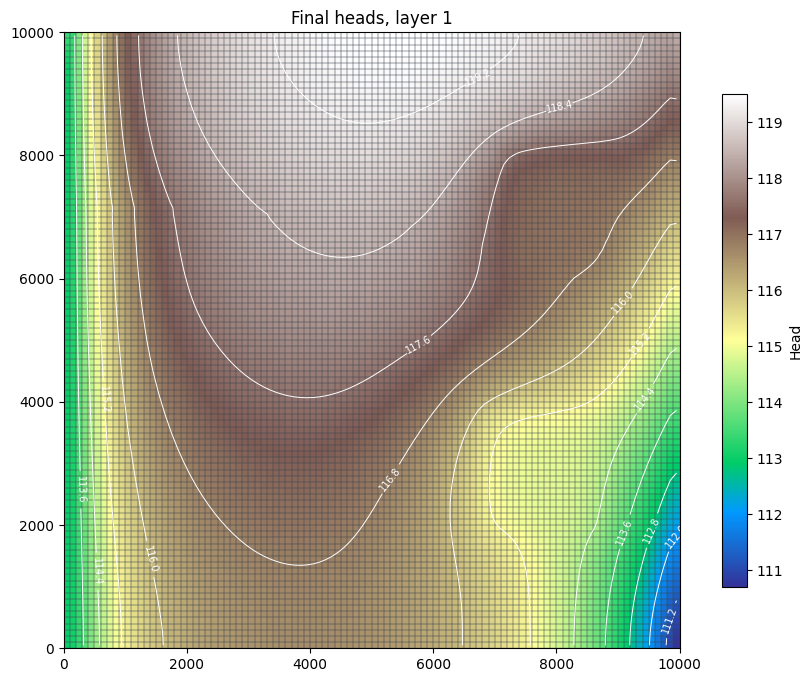

In [8]:
map_style = mf.ModelMapStyle(figsize=(11, 8), cmap="terrain", contour_levels=12, dpi=100)
fig, ax = mf.plot_model_head_map(model, head_frames[-1], layer=0, style=map_style, title="Final heads, layer 1")
plt.show()

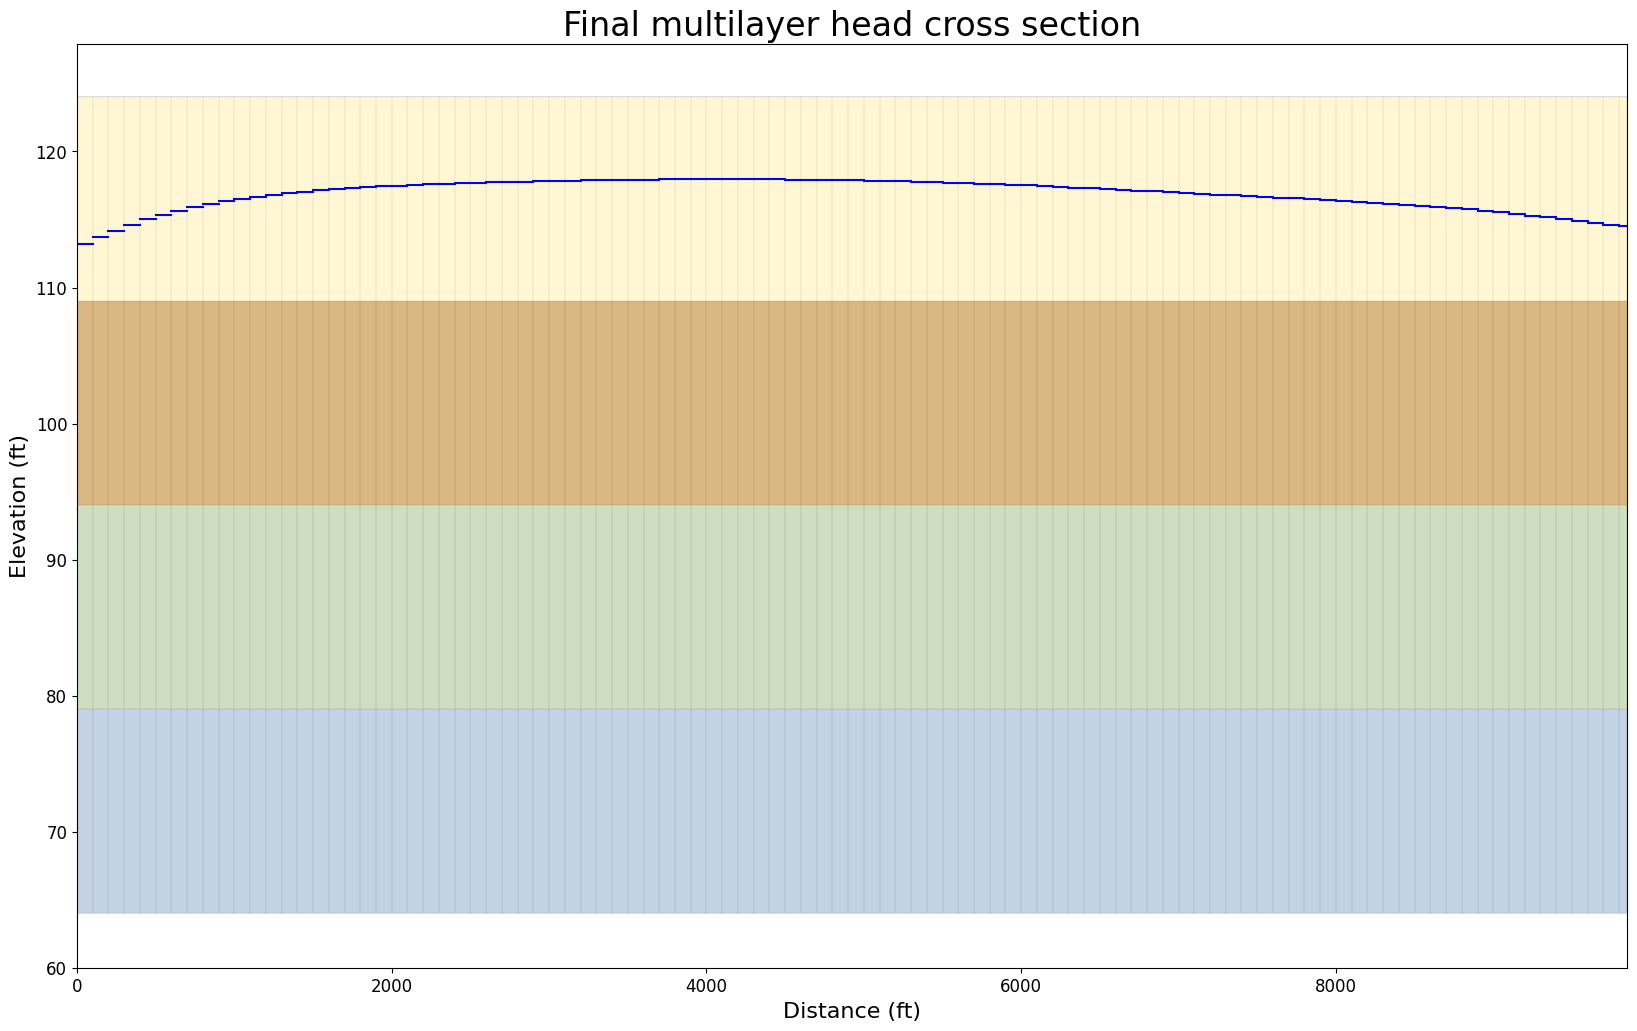

In [9]:
section_line = LineString([(config.cell_size * 0.5, config.cell_size * config.nrow * 0.5), (config.cell_size * (config.ncol - 0.5), config.cell_size * config.nrow * 0.5)])
fig, ax = plot_model_cross_section(model, section_line, head_data=head_frames[-1], show_legend=False, title="Final multilayer head cross section")
plt.show()

## 5. Standalone Matplotlib HTML sliders

`embed_frames=True` creates one portable HTML file. For this large model, `embed_frames=False` is preferred: it writes PNG frames beside a small HTML controller and avoids assembling every base64 image in memory. External-frame exports are resumable, report progress, reject concurrent writers, and support `frame_stride` / `max_frames` for bounded review runs.

In [10]:
embedded_preview = model.visualize.head_map_slider_html(
    html_dir / "head_map_embedded_preview.html",
    head_frames=head_frames[:2],
    labels=[str(value) for value in kstpkpers[:2]],
    layer=0,
    style=mf.ModelMapStyle(show_contours=False, dpi=75),
    embed_frames=True,
)
assert embedded_preview.embedded_frames and embedded_preview.path.exists()
embedded_preview

StandaloneHtmlSlider(path=WindowsPath('C:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/master_visualization_prt_full_20260606_174842/html/head_map_embedded_preview.html'), labels=('(np.int32(0), np.int32(0))', '(np.int32(1), np.int32(0))'), frame_count=2, title='Head map through time', embedded_frames=True, frame_directory=None, rendered_frames=2, reused_frames=0)

In [11]:
head_slider = model.visualize.head_map_slider_html(
    html_dir / "head_map_all_times.html",
    layer=0,
    style=mf.ModelMapStyle(show_contours=True, contour_levels=10, dpi=85),
    embed_frames=False,
    frame_stride=FRAME_STRIDE,
    max_frames=MAX_FRAMES,
    resume=RESUME_EXPORTS,
    progress=True,
)
sliders = [head_slider]
if EXPORT_ALL_SLIDERS:
    sliders.extend([
        model.visualize.head_layer_mosaic_slider_html(
            html_dir / "head_mosaic_all_layers.html",
            layers=list(range(config.nlay)),
            ncols=2,
            style=mf.ModelMapStyle(show_contours=False, dpi=70, figsize=(6, 5)),
            embed_frames=False,
            frame_stride=FRAME_STRIDE,
            max_frames=MAX_FRAMES,
            resume=RESUME_EXPORTS,
            progress=True,
        ),
        model.visualize.cross_section_slider_html(
            section_line,
            html_dir / "head_cross_section_all_times.html",
            show_legend=False,
            dpi=80,
            embed_frames=False,
            frame_stride=FRAME_STRIDE,
            max_frames=MAX_FRAMES,
            resume=RESUME_EXPORTS,
            progress=True,
        ),
    ])

for slider in sliders:
    assert slider.path.exists()
    expected_frames = len(kstpkpers[::FRAME_STRIDE]) if MAX_FRAMES is None else min(MAX_FRAMES, len(kstpkpers[::FRAME_STRIDE]))
    assert slider.frame_count == expected_frames
    assert slider.frame_directory is not None
    assert len(list(slider.frame_directory.glob("*.png"))) >= expected_frames

[slider.path for slider in sliders]

[1/12] rendered: kstpkper=(np.int32(0), np.int32(0))
[2/12] rendered: kstpkper=(np.int32(1), np.int32(0))
[3/12] rendered: kstpkper=(np.int32(0), np.int32(1))
[4/12] rendered: kstpkper=(np.int32(1), np.int32(1))
[5/12] rendered: kstpkper=(np.int32(0), np.int32(2))
[6/12] rendered: kstpkper=(np.int32(1), np.int32(2))
[7/12] rendered: kstpkper=(np.int32(0), np.int32(3))
[8/12] rendered: kstpkper=(np.int32(1), np.int32(3))
[9/12] rendered: kstpkper=(np.int32(0), np.int32(4))
[10/12] rendered: kstpkper=(np.int32(1), np.int32(4))
[11/12] rendered: kstpkper=(np.int32(0), np.int32(5))
[12/12] rendered: kstpkper=(np.int32(1), np.int32(5))
[1/12] rendered: kstpkper=(np.int32(0), np.int32(0))
[2/12] rendered: kstpkper=(np.int32(1), np.int32(0))
[3/12] rendered: kstpkper=(np.int32(0), np.int32(1))
[4/12] rendered: kstpkper=(np.int32(1), np.int32(1))
[5/12] rendered: kstpkper=(np.int32(0), np.int32(2))
[6/12] rendered: kstpkper=(np.int32(1), np.int32(2))
[7/12] rendered: kstpkper=(np.int32(0), np.

[WindowsPath('C:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/master_visualization_prt_full_20260606_174842/html/head_map_all_times.html'),
 WindowsPath('C:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/master_visualization_prt_full_20260606_174842/html/head_mosaic_all_layers.html'),
 WindowsPath('C:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/master_visualization_prt_full_20260606_174842/html/head_cross_section_all_times.html')]

## 6. Plotly animations

These preserve the existing `myflopy` Plotly workflows while exporting standalone HTML with every stress-period/timestep frame.

In [12]:
plotly_map = model.visualize.plotly_head_map_animation(
    output_path=html_dir / "plotly_head_map.html",
    layer=0,
    show_layer_elevs=False,
    hover_heads=True,
    frame_stride=FRAME_STRIDE,
    max_frames=MAX_FRAMES,
)
assert len(plotly_map.frames) == expected_frames
plotly_map.show()

In [13]:
plotly_section = None
if EXPORT_PLOTLY_SECTION:
    plotly_section = model.visualize.plotly_cross_section_animation(
        output_path=html_dir / "plotly_head_cross_section.html",
        cells=cells["cross_section"],
        layer=list(range(config.nlay)),
        interpolate=False,
        use_rbf=False,
        frame_stride=FRAME_STRIDE,
        max_frames=MAX_FRAMES,
    )
    assert len(plotly_section.frames) == expected_frames
plotly_section

reading master_complex data...
loading simulation...0)
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package disv...
    skipping package ic...
    skipping package npf...
    skipping package sto...
    skipping package chd...
    skipping package ghb...
    skipping package drn...
    skipping package lak...
    skipping package sfr...
    skipping package mvr...
    skipping package uzf...
    skipping package obs...
    skipping package oc...
    skipping package ims6...


## 7. Canonical target and package-result review

Targets remain independent of PEST. They can inspect the real MF6 observation files or package results produced above.

In [14]:
simulated_targets = {
    "heads": model.targets.heads.targets.simulated_heads(model),
    "lake_stage": model.targets.lake_stage.targets.simulated_series(model),
    "sfr_stage": model.targets.sfr_stage.targets.simulated_series(model),
    "sfr_flow": model.targets.sfr_flow.targets.simulated_series(model),
    "drn_flow": model.targets.drn_flow.targets.simulated_series(model),
}
assert all(not frame.empty for frame in simulated_targets.values())
{name: frame.shape for name, frame in simulated_targets.items()}

C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[str(name)] = _clean_observation_output_values(frame[actual])
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  result[str(name)] = _clean_observation_output_values(frame[actual])
C:\Users\lukem\Python\Projects\myflopy\src\myflopy\modflow\mf6\observations.py:155: PerformanceWarning: DataFrame is highly fragmented.  T

{'heads': (6, 4),
 'lake_stage': (12, 3),
 'sfr_stage': (12, 3),
 'sfr_flow': (12, 3),
 'drn_flow': (12, 3)}

In [15]:
package_review = {
    "lake_stage_rows": len(model.packages.lak.results.stage.get()),
    "sfr_exchange_rows": len(model.packages.sfr.results.q.get()),
    "uzf_ifno_count": len(model.outputs.uzf.ifno_to_cellid),
    "budget_terms": model.bud().types,
}
package_review

{'lake_stage_rows': 16464,
 'sfr_exchange_rows': 1200,
 'uzf_ifno_count': 9172,
 'budget_terms': [np.str_('          STO-SS'),
  np.str_('          STO-SY'),
  np.str_('    FLOW-JA-FACE'),
  np.str_('      DATA-SPDIS'),
  np.str_('        DATA-SAT'),
  np.str_('             DRN'),
  np.str_('             GHB'),
  np.str_('             CHD'),
  np.str_('             SFR'),
  np.str_('             LAK'),
  np.str_('       UZF-GWRCH')]}

## 8. MF6 PRT particle tracking

PRT is a separate MF6 simulation that copies the GWF DISV grid and timing, then consumes completed GWF head and budget outputs through FMI. MP3DU remains available through `model.particle_tracking.mp3du(...)`, but PRT is the preferred integrated engine.

In [16]:
release_points = mf.PRTReleasePoints.from_cells(
    model,
    cells=cells["releases"],
    layer=0,
    local_z=0.5,
)
prt_project = model.particle_tracking.prt(
    workspace=artifact_root / "prt",
    release_points=release_points,
    porosity=0.25,
    stop_at_weak_sink=False,
)
prt_project.write()
assert (prt_project.workspace / "mfsim.nam").exists()
prt_project.workspace

WindowsPath('C:/Users/lukem/Python/Projects/simple_modflow/examples/mf6/artifacts/master_visualization_prt_full_20260606_174842/prt')

In [17]:
prt_result = prt_project.run(write=False, silent=True) if RUN_PRT else None
if prt_result is not None:
    assert prt_result.success
    assert not prt_result.pathlines.empty
    display(prt_result.pathlines.head())
    display(prt_result.terminal_points.head())

,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
0,1,1,1,1,1,1,2503,0,1,0,0.0,0.0,250.000000,2550.000000,109.905365,NaN
1,1,1,1,1,1,1,2503,0,1,2,0.0,15.0,249.520744,2549.998564,109.895025,NaN
2,1,1,1,1,2,1,5003,0,1,0,0.0,0.0,250.000000,5050.000000,110.912343,NaN
3,1,1,1,1,2,1,5003,0,1,2,0.0,15.0,249.391003,5049.996301,110.904907,NaN
4,1,1,1,1,3,1,7503,0,1,0,0.0,0.0,250.000000,7550.000000,111.919402,NaN


,kper,kstp,imdl,iprp,irpt,ilay,icell,izone,istatus,ireason,trelease,t,x,y,z,name
134,6,2,1,1,1,4,32501,0,5,3,0.0,1841.670460,45.212620,2548.113818,77.0,NaN
142,6,2,1,1,2,4,35001,0,5,3,0.0,1602.103250,38.606701,5048.693008,79.0,NaN
149,6,2,1,1,3,4,37501,0,5,3,0.0,1481.037863,35.220525,7548.032500,81.0,NaN
157,6,2,1,1,1,4,32501,0,5,3,30.0,1867.361805,44.613695,2548.075547,77.0,NaN
165,6,2,1,1,2,4,35001,0,5,3,30.0,1614.945146,37.907105,5048.686387,79.0,NaN


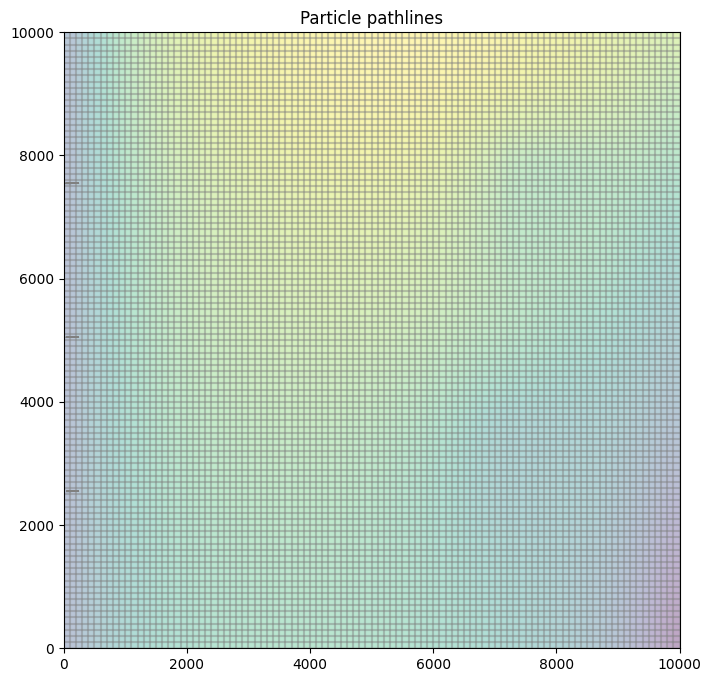

C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\trame_vtk\modules\vtk\serializers\data.py:43: DeprecationWarning: Call to deprecated method GetData. (Use ExportLegacyFormat, or GetOffsetsArray/GetConnectivityArray instead.) -- Deprecated since version 9.6.0.
  if dataset.GetVerts() and dataset.GetVerts().GetData().GetNumberOfTuples() > 0:
C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\trame_vtk\modules\vtk\serializers\data.py:49: DeprecationWarning: Call to deprecated method GetData. (Use ExportLegacyFormat, or GetOffsetsArray/GetConnectivityArray instead.) -- Deprecated since version 9.6.0.
  if dataset.GetLines() and dataset.GetLines().GetData().GetNumberOfTuples() > 0:
C:\Users\lukem\Python\mf-env\.venv\Lib\site-packages\trame_vtk\modules\vtk\serializers\data.py:55: DeprecationWarning: Call to deprecated method GetData. (Use ExportLegacyFormat, or GetOffsetsArray/GetConnectivityArray instead.) -- Deprecated since version 9.6.0.
  if dataset.GetPolys() and dataset.GetPolys

C:\Users\lukem\Python\Projects\myflopy\examples\mf6\artifacts\master_visualization_prt_full_20260606_174842\html\prt_particle_scene.html


In [18]:
if prt_result is not None:
    fig, ax = prt_result.plot_map(head_data=head_frames[-1], head_layer=0)
    plt.show()

    reopened = mf.open_prt_run(model, prt_project.workspace)
    assert len(reopened.pathlines) == len(prt_result.pathlines)

    if EXPORT_3D:
        particle_html = reopened.export_3d_html(
            html_dir / "prt_particle_scene.html",
            vertical_exaggeration=5.0,
        )
        assert particle_html.exists()
        print(particle_html)

## 9. Final integration audit

This final cell makes the notebook act like an integration test. If it completes, the model, complex packages, canonical observations, result readers, Matplotlib sliders, Plotly animations, and optional PRT/PyVista export all worked together.

In [19]:
audit = {
    "profile": PROFILE,
    "ncpl": config.ncpl,
    "nlay": config.nlay,
    "total_gwf_cells": config.ncpl * config.nlay,
    "saved_head_frames": len(kstpkpers),
    "packages": sorted(required_packages),
    "standalone_html_exports": len(list(html_dir.glob("*.html"))),
    "prt_ran": prt_result is not None,
    "prt_rows": 0 if prt_result is None else len(prt_result.pathlines),
}
minimum_exports = 7 if EXPORT_ALL_SLIDERS and EXPORT_PLOTLY_SECTION and EXPORT_3D else 3
assert audit["standalone_html_exports"] >= minimum_exports
pd.Series(audit, name="master workflow audit")

profile                                                                 full
ncpl                                                                   10000
nlay                                                                       4
total_gwf_cells                                                        40000
saved_head_frames                                                         12
packages                   [chd, disv, drn, ghb, lak, mvr, npf, oc, sfr, ...
standalone_html_exports                                                    7
prt_ran                                                                 True
prt_rows                                                                 270
Name: master workflow audit, dtype: object